In [14]:
import numpy as np
import matplotlib.pyplot as plt
from diag_operator_build_wf import *
import matplotlib.colors as colours
from tqdm.notebook import tqdm
import sys

plt.rcParams["figure.dpi"] = 150

In [2]:
def localized_state(size):
    psi0 = np.zeros(size, dtype = complex)
    beg = int(0.35*size)
    end = int(0.65*size)
    psi0[beg:end] = np.random.uniform(-1, 1, end-beg) + 1j * np.random.uniform(-1, 1, end-beg)
    psi0 /= np.linalg.norm(psi0)
    
    return psi0

def time_evol_symmetry_negativity(N, n, k, alpha, beta):

    neg1 = np.zeros(n)

    psi0 = localized_state(N)
    W0 = wigner_function(np.outer(psi0, psi0.conj())).real
    neg1[0] = np.sum((np.abs(W0)-W0))/2

    for i in range(1, n):
        U = diagonalize_floquet_operator(N, alpha, beta, k)
        psi = U@psi0
        rho = np.outer(psi, psi.conj())
        W = wigner_function(rho).real  
        neg1[i] = np.sum((np.abs(W) - W))/2
        psi0 = psi

    return neg1

def alpha_beta_dependence(alphas, betas, k, N, n):
    neg = np.zeros((len(alphas), len(betas)))

    pbar = tqdm(total=len(alphas) * len(betas),desc=r"$(\alpha,\beta)$",position=0,leave=True,file=sys.stdout)

    for i in range(len(alphas)):
        for j in range(len(betas)):
            neg[i, j] = time_evol_symmetry_negativity(N, n, k, alphas[i], betas[j])[-1]
            pbar.update(1)

    pbar.close()

    return neg

In [3]:
alphas = np.round(np.linspace(0, 1, 25),3)
betas = alphas.copy()

$(\alpha,\beta)$:   0%|          | 0/625 [00:00<?, ?it/s]

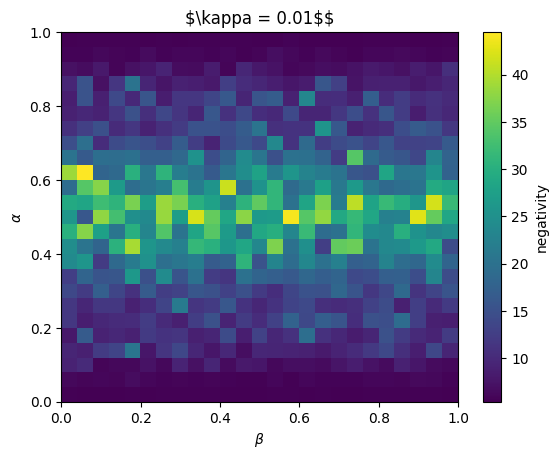

In [ ]:
neg1 = alpha_beta_dependence(betas, alphas, 0.01, 401, 10)

plt.imshow(neg1,origin="lower",aspect="auto",extent=[betas[0], betas[-1], alphas[0], alphas[-1]],cmap="viridis")
plt.colorbar(label="negativity")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\alpha$")
plt.title(rf"$\kappa = {0.01}$$")
plt.show()

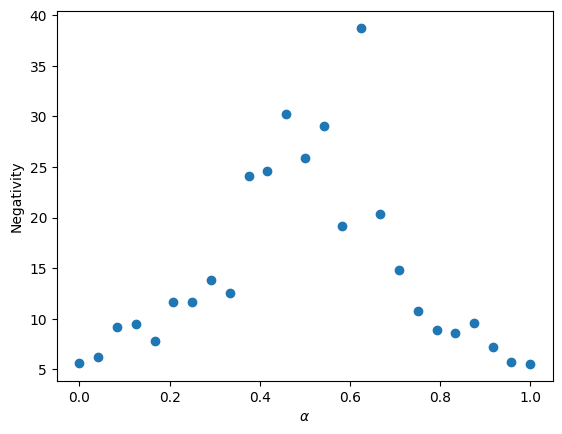

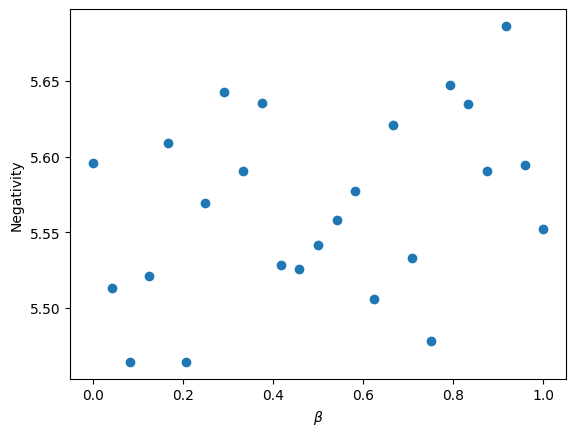

In [5]:
plt.scatter(alphas, neg1[:, 0])
plt.xlabel(r"$\alpha$")
plt.ylabel("Negativity")
plt.show()

plt.scatter(alphas, neg1[0])
plt.xlabel(r"$\beta$")
plt.ylabel("Negativity")
plt.show()

$(\alpha,\beta)$:   0%|          | 0/625 [00:00<?, ?it/s]

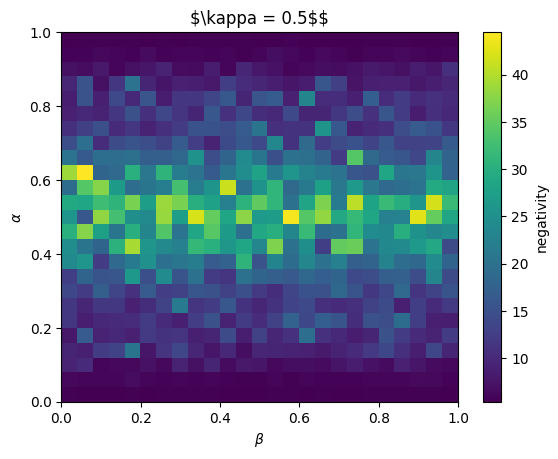

In [ ]:
neg2 = alpha_beta_dependence(betas, alphas, 0.5, 401, 10)

plt.imshow(neg1,origin="lower",aspect="auto",extent=[betas[0], betas[-1], alphas[0], alphas[-1]],cmap="viridis")
plt.colorbar(label="negativity")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\alpha$")
plt.title(rf"$\kappa = {0.5}$$")
plt.show()

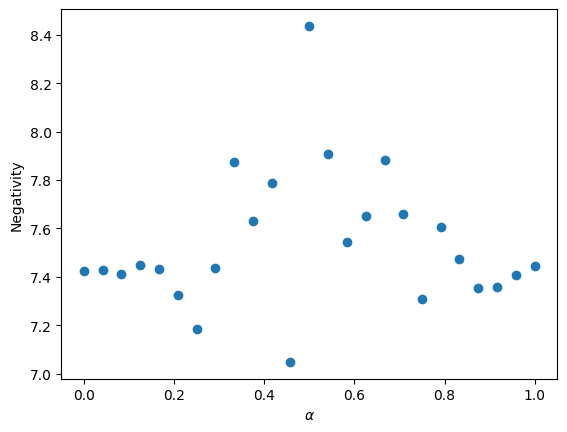

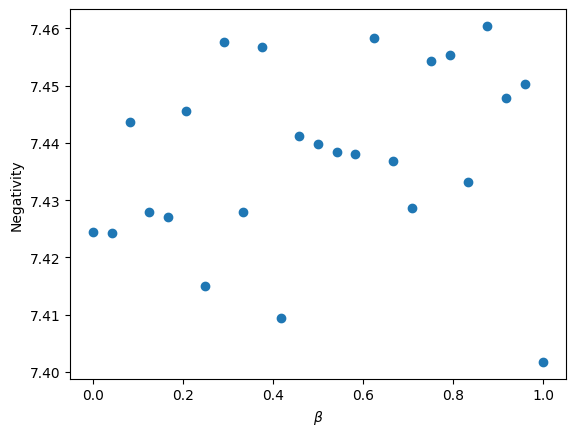

In [7]:
plt.scatter(alphas, neg2[:, 0])
plt.xlabel(r"$\alpha$")
plt.ylabel("Negativity")
plt.show()

plt.scatter(alphas, neg2[0])
plt.xlabel(r"$\beta$")
plt.ylabel("Negativity")
plt.show()

$(\alpha,\beta)$:   0%|          | 0/625 [00:00<?, ?it/s]

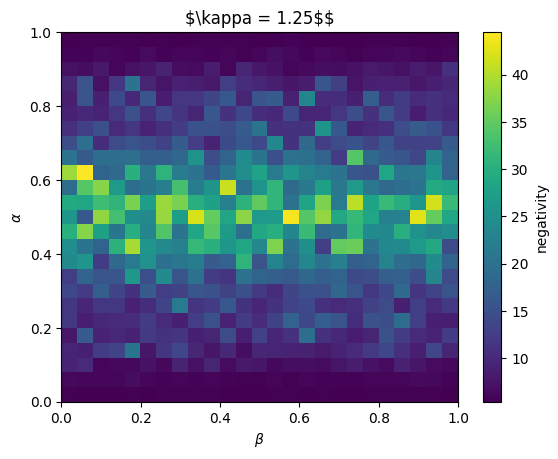

In [8]:
neg3 = alpha_beta_dependence(alphas, betas, 1.25, 401, 10)

plt.imshow(neg1,origin="lower",aspect="auto",extent=[betas[0], betas[-1], alphas[0], alphas[-1]],cmap="viridis")
plt.colorbar(label="negativity")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\alpha$")
plt.title(rf"$\kappa = {1.25}$$")
plt.show()

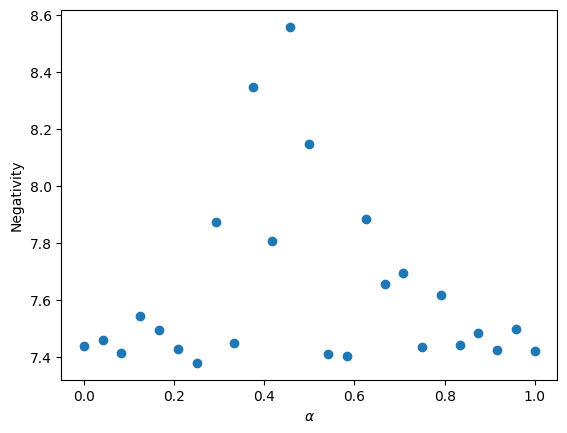

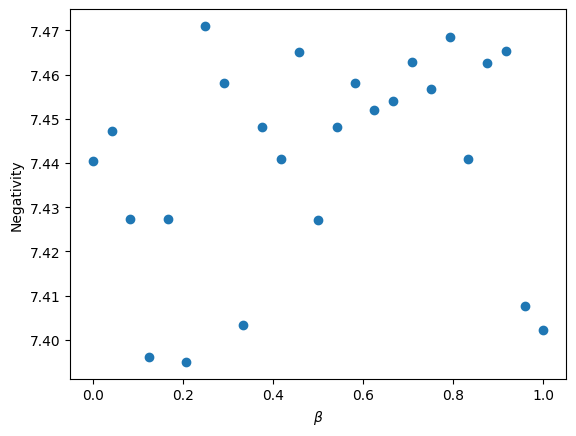

In [9]:
plt.scatter(alphas, neg3[:, 0])
plt.xlabel(r"$\alpha$")
plt.ylabel("Negativity")
plt.show()

plt.scatter(alphas, neg3[0])
plt.xlabel(r"$\beta$")
plt.ylabel("Negativity")
plt.show()

$(\alpha,\beta)$:   0%|          | 0/625 [00:00<?, ?it/s]

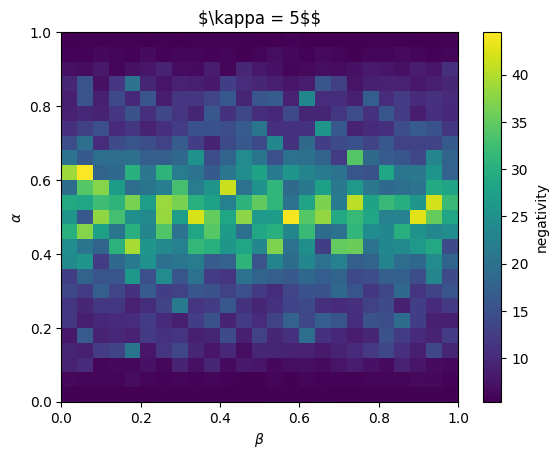

In [10]:
neg4 = alpha_beta_dependence(alphas, betas, 5, 401, 10)

plt.imshow(neg1,origin="lower",aspect="auto",extent=[betas[0], betas[-1], alphas[0], alphas[-1]],cmap="viridis")
plt.colorbar(label="negativity")
plt.xlabel(r"$\beta$")
plt.ylabel(r"$\alpha$")
plt.title(rf"$\kappa = {5}$$")
plt.show()

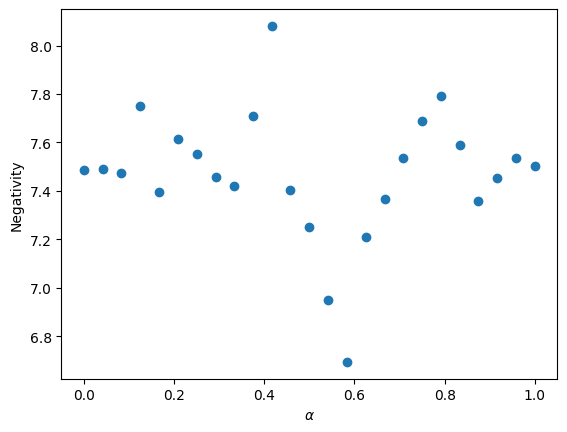

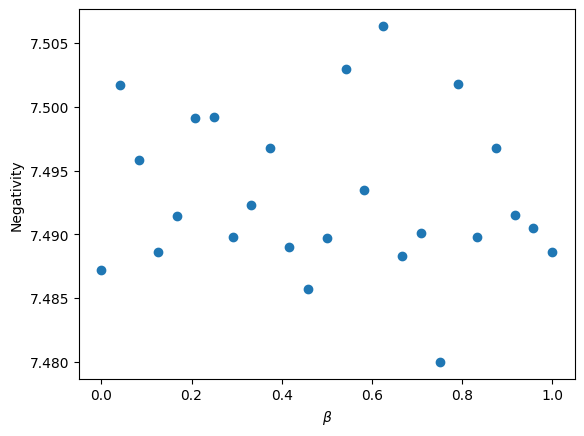

In [11]:
plt.scatter(alphas, neg4[:, 0])
plt.xlabel(r"$\alpha$")
plt.ylabel("Negativity")
plt.show()

plt.scatter(alphas, neg4[0])
plt.xlabel(r"$\beta$")
plt.ylabel("Negativity")
plt.show()

Near integrable and maximally chaotic regions

$(\alpha,\beta)$:   0%|          | 0/625 [00:00<?, ?it/s]

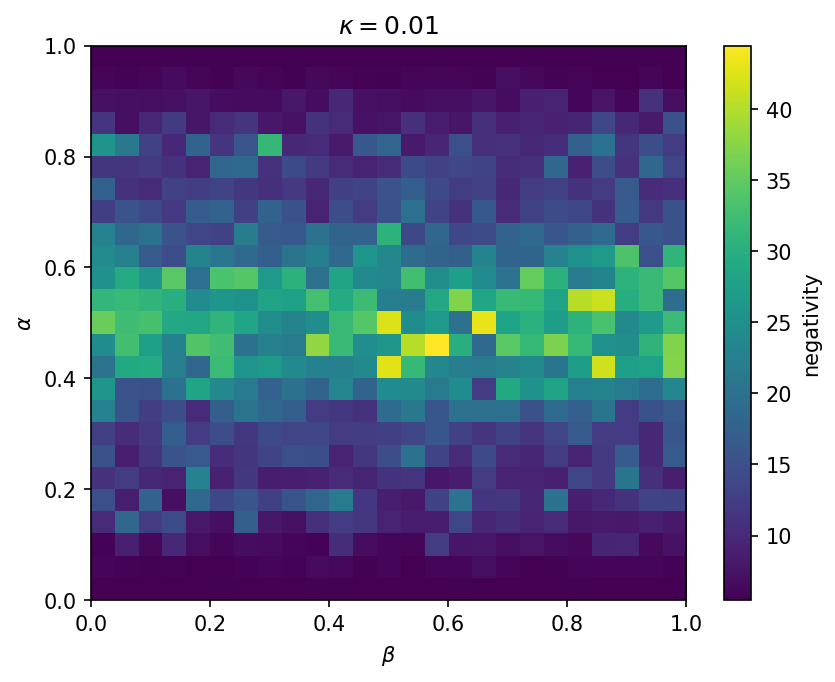

In [ ]:
neg_int = alpha_beta_dependence(betas, alphas, 0.01, 401, 10)

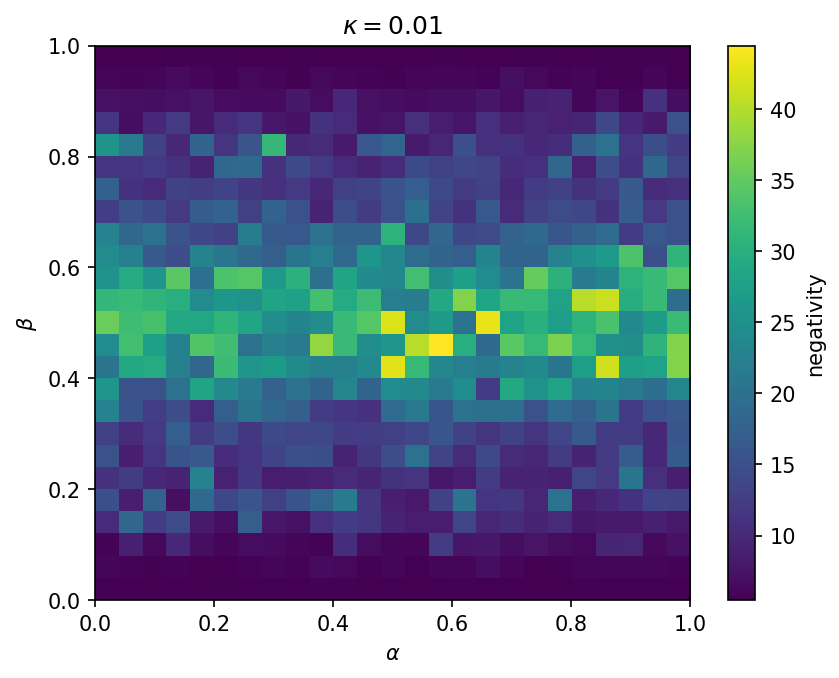

In [29]:
plt.imshow(neg_int,origin="lower",aspect="auto",extent=[betas[0], betas[-1], alphas[0], alphas[-1]],cmap="viridis")
plt.colorbar(label="negativity")
plt.ylabel(r"$\beta$")
plt.xlabel(r"$\alpha$")
plt.title(rf"$\kappa = {0.01}$")
plt.show()

In [24]:
alphas

array([0.   , 0.042, 0.083, 0.125, 0.167, 0.208, 0.25 , 0.292, 0.333,
       0.375, 0.417, 0.458, 0.5  , 0.542, 0.583, 0.625, 0.667, 0.708,
       0.75 , 0.792, 0.833, 0.875, 0.917, 0.958, 1.   ])

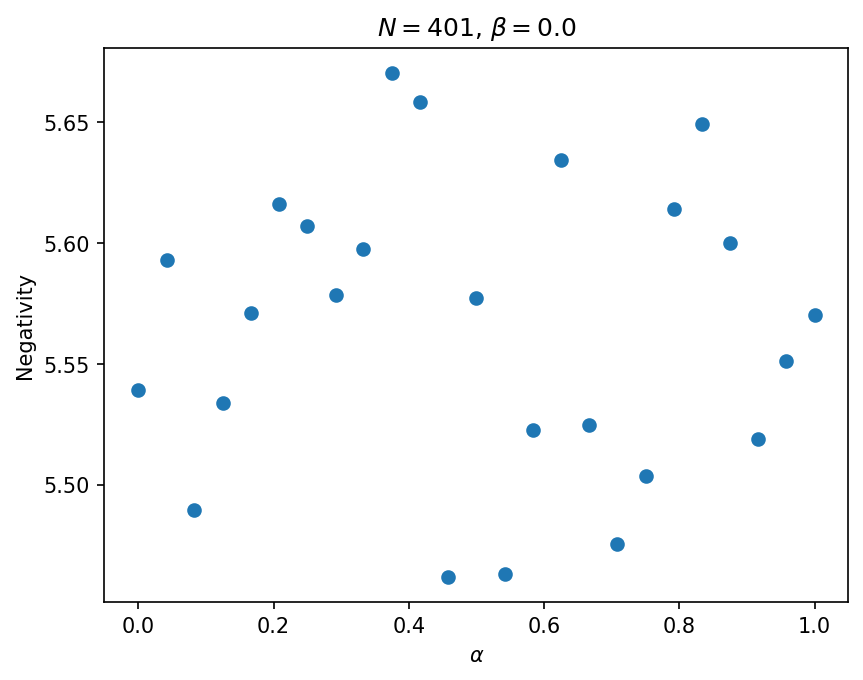

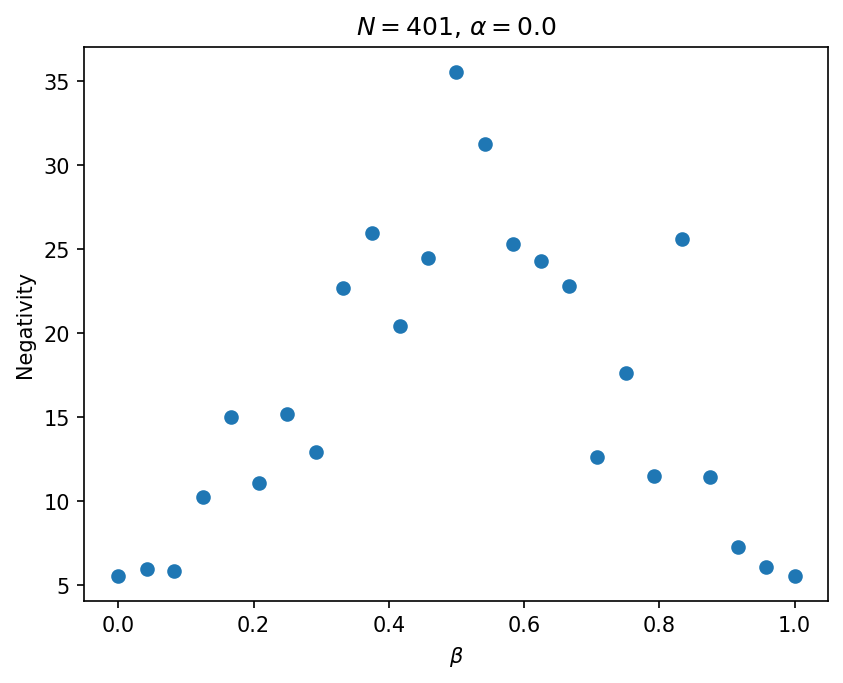

In [27]:
plt.scatter(alphas, neg_int[0])
plt.xlabel(rf"$\alpha$")
plt.ylabel("Negativity")
plt.title(rf"$N = {401}$, $\beta = {betas[0]}$")
plt.show()

plt.scatter(alphas, neg_int[:, 0])
plt.xlabel(rf"$\beta$")
plt.ylabel("Negativity")
plt.title(rf"$N = {401}$, $\alpha = {alphas[0]}$")
plt.show()


$(\alpha,\beta)$:   0%|          | 0/625 [00:00<?, ?it/s]

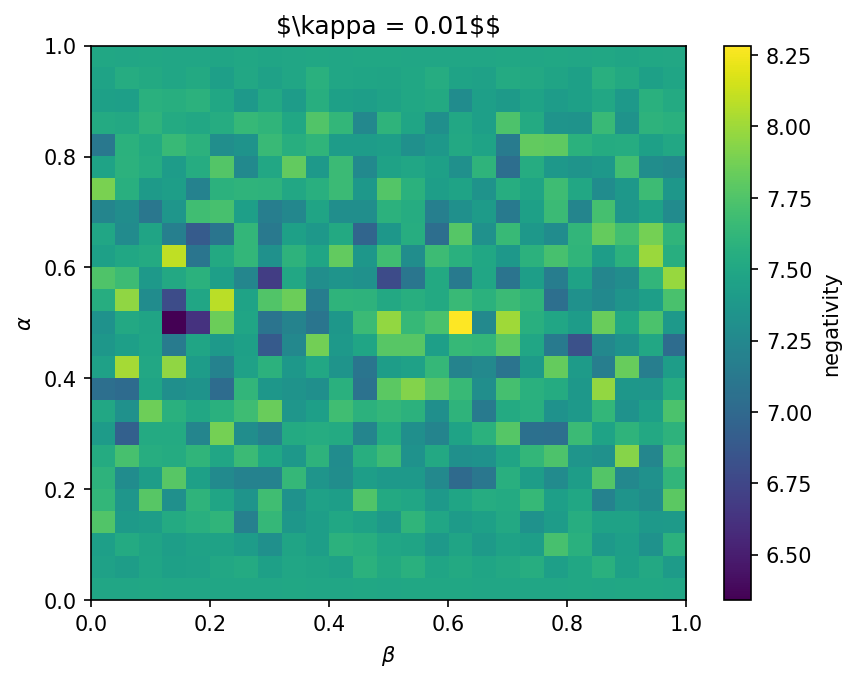

In [ ]:
neg_chaotic = alpha_beta_dependence(betas, alphas, 10, 401, 10)

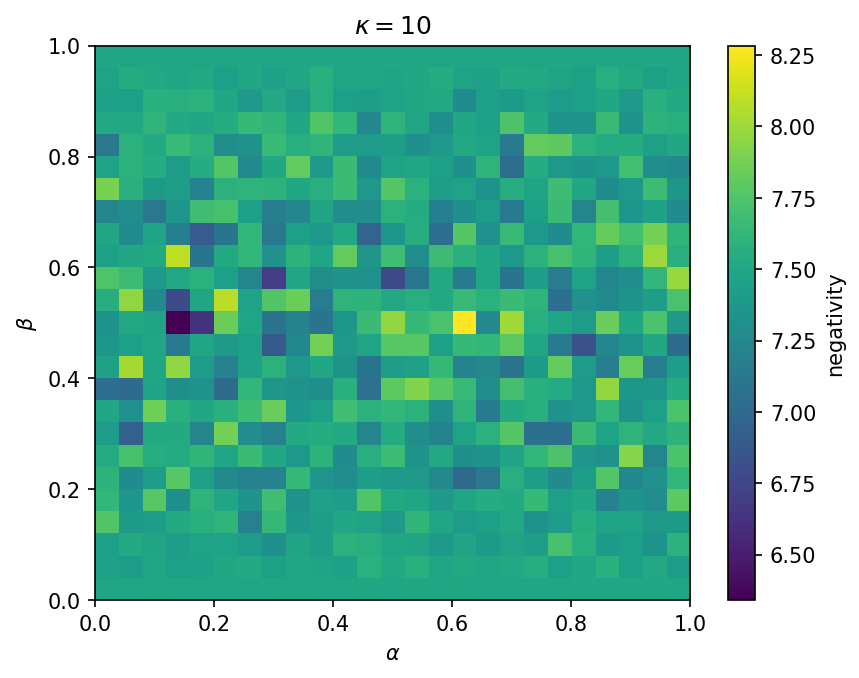

In [30]:
plt.imshow(neg_chaotic,origin="lower",aspect="auto",extent=[betas[0], betas[-1], alphas[0], alphas[-1]],cmap="viridis")
plt.colorbar(label="negativity")
plt.ylabel(r"$\beta$")
plt.xlabel(r"$\alpha$")
plt.title(rf"$\kappa = {10}$")
plt.show()

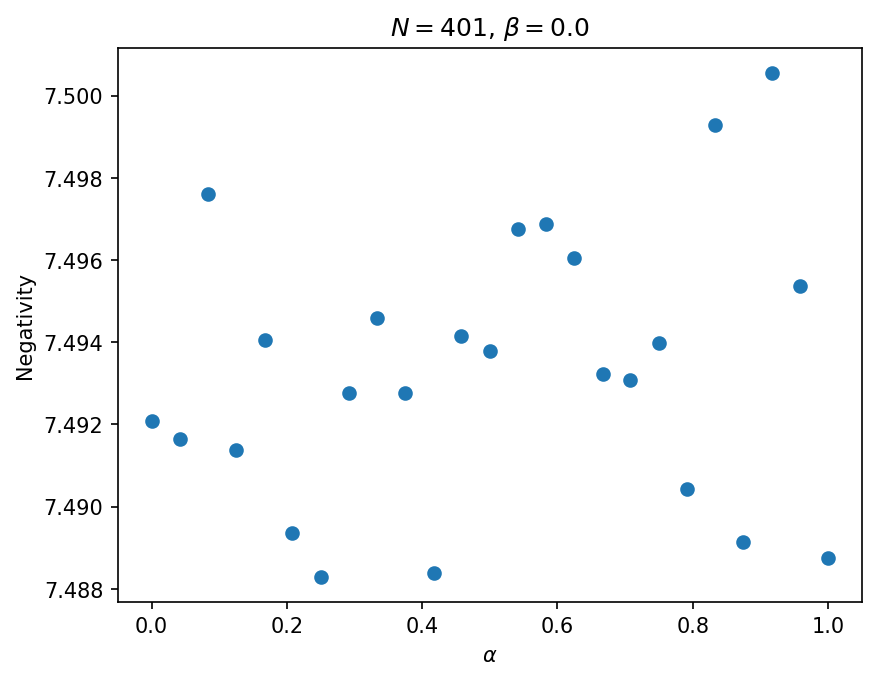

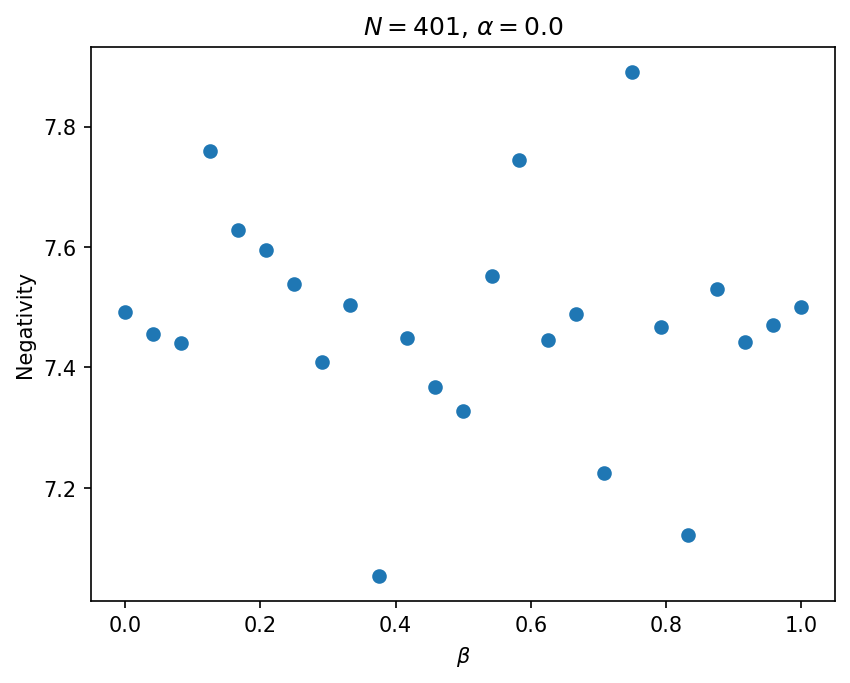

In [28]:
plt.scatter(alphas, neg_chaotic[0])
plt.xlabel(rf"$\alpha$")
plt.ylabel("Negativity")
plt.title(rf"$N = {401}$, $\beta = {betas[0]}$")
plt.show()

plt.scatter(alphas, neg_chaotic[:, 0])
plt.xlabel(rf"$\beta$")
plt.ylabel("Negativity")
plt.title(rf"$N = {401}$, $\alpha = {alphas[0]}$")
plt.show()
